In [ ]:
# Cell 1 — Mount Drive, install packages and define paths

from google.colab import drive
drive.mount('/content/drive')

!pip install -q pandas numpy pyarrow scikit-learn scipy matplotlib seaborn joblib tqdm

import os
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from scipy.signal import medfilt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, HuberRegressor, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

ROOT = "/content/drive/MyDrive/fitrec_processed"
IN_PATH = f"{ROOT}/sampled_rides.parquet"

OUT_ROOT = "/content/drive/MyDrive/hr_zone_rebuild_v1"
CHK_DIR = f"{OUT_ROOT}/checkpoints"
FIG_DIR = f"{OUT_ROOT}/figures"
TAB_DIR = f"{OUT_ROOT}/tables"
DEMO_DIR = f"{OUT_ROOT}/demo_exports"
MODEL_DIR = f"{OUT_ROOT}/models"

for d in [OUT_ROOT, CHK_DIR, FIG_DIR, TAB_DIR, DEMO_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print("Paths ready")
print("Input:", IN_PATH)
print("Output root:", OUT_ROOT)


Mounted at /content/drive
Paths ready
Input: /content/drive/MyDrive/fitrec_processed/sampled_rides.parquet
Output root: /content/drive/MyDrive/hr_zone_rebuild_v1


In [ ]:
# Cell 2 - Parameters

RESAMPLE_SECONDS = 5

W30 = int(30 / RESAMPLE_SECONDS)
W60 = int(60 / RESAMPLE_SECONDS)
W120 = int(120 / RESAMPLE_SECONDS)
W300 = int(300 / RESAMPLE_SECONDS)
W600 = int(600 / RESAMPLE_SECONDS)

AGE = 24
HRMAX = 220 - AGE

CFG = {
    "min_speed_kmh": 4.0,
    "min_active_power": 35.0,

    # relaxed steady logic
    "steady_pstd120_max": 22.0,
    "steady_pjump5_max": 55.0,
    "steady_grade_std120_max": 0.015,
    "steady_speed_std120_max": 3.0,

    "min_steady_block_sec": 180,
    "fit_window_sec": 900,
    "min_fit_samples": 36,

    "drift_start_min": 15,
    "drift_clip_bpm": 15.0,
    "resid_pos_thresh": 1.25,
    "resid_persist_sec": 30,
    "drift_alpha": 0.025,
    "drift_decay_on_steady": 0.992,

    "debounce_on_sec": 30,
    "debounce_off_sec": 20,
    "hold_gap_sec": 20,

    "eval_early_min": 6,
    "eval_late_min": 6,
    "eval_min_samples_each": 15,

    "demo_min_duration_min": 50
}

with open(f"{OUT_ROOT}/config_relaxed_v1.json", "w") as f:
    json.dump(CFG, f, indent=2)

print(CFG)



{'min_speed_kmh': 4.0, 'min_active_power': 35.0, 'steady_pstd120_max': 22.0, 'steady_pjump5_max': 55.0, 'steady_grade_std120_max': 0.015, 'steady_speed_std120_max': 3.0, 'min_steady_block_sec': 180, 'fit_window_sec': 900, 'min_fit_samples': 36, 'drift_start_min': 15, 'drift_clip_bpm': 15.0, 'resid_pos_thresh': 1.25, 'resid_persist_sec': 30, 'drift_alpha': 0.025, 'drift_decay_on_steady': 0.992, 'debounce_on_sec': 30, 'debounce_off_sec': 20, 'hold_gap_sec': 20, 'eval_early_min': 6, 'eval_late_min': 6, 'eval_min_samples_each': 15, 'demo_min_duration_min': 50}


In [ ]:
print("Checkpoint directory:", CHK_DIR)
print("Available checkpoints:")
for f in sorted(os.listdir(CHK_DIR)):
    print("-", f)

Checkpoint directory: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints
Available checkpoints:
- 01_features.parquet
- 02_features_steady.parquet
- 02_features_steady_relaxed_v1.parquet
- 03_expected_hr.parquet
- 03_expected_hr_relaxed_v1.parquet
- 04_final_with_drift.parquet
- 04_final_with_drift_relaxed_v1.parquet


In [ ]:
df_model = load_ckpt("03_expected_hr_relaxed_v1")
df_final = load_ckpt("04_final_with_drift_relaxed_v1")

Loaded: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/03_expected_hr_relaxed_v1.parquet rows: 2213504
Loaded: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/04_final_with_drift_relaxed_v1.parquet rows: 2213504


In [ ]:
# Cell 3 - Load data

df = pd.read_parquet(IN_PATH).copy()

base_cols = ["timestamp","elapsed_seconds","hr","speed","altitude","ride_id","cyclist_id","gender"]
latlon_cols = [c for c in ["latitude","longitude"] if c in df.columns]
keep_cols = base_cols + latlon_cols
df = df[keep_cols].copy()

for c in ["elapsed_seconds","hr","speed","altitude"] + latlon_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["ride_id","cyclist_id","elapsed_seconds","hr","speed","altitude"]).copy()
df = df.sort_values(["ride_id","elapsed_seconds"]).reset_index(drop=True)

print("Rows:", len(df))
print("Rides:", df["ride_id"].nunique())
print("Cyclists:", df["cyclist_id"].nunique())
print(df[["hr","speed","altitude","elapsed_seconds"]].describe())


Rows: 2316019
Rides: 3535
Cyclists: 422
                 hr         speed      altitude  elapsed_seconds
count  2.316019e+06  2.316019e+06  2.316019e+06     2.316019e+06
mean   1.387371e+02  2.615545e+01  1.287299e+02     1.736060e+03
std    2.056967e+01  9.018953e+00  3.511952e+02     1.100763e+03
min    5.300000e+01  0.000000e+00 -5.000000e+02     0.000000e+00
25%    1.250000e+02  2.111760e+01  1.060000e+01     8.150000e+02
50%    1.399792e+02  2.671560e+01  4.460000e+01     1.635000e+03
75%    1.530000e+02  3.179160e+01  1.302000e+02     2.540000e+03
max    2.190000e+02  2.106180e+02  9.826200e+03     4.975000e+03


In [ ]:
# Cell 4 - Helper functions

def haversine_m(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def robust_clip(x, k=6.0):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med)) + 1e-9
    s = 1.4826 * mad
    return np.clip(x, med - k*s, med + k*s)

def longest_true_blocks(mask):
    mask = np.asarray(mask, dtype=bool)
    blocks = []
    start = None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        if not v and start is not None:
            blocks.append((start, i-1))
            start = None
    if start is not None:
        blocks.append((start, len(mask)-1))
    return blocks

def debounce_hold(mask, on_n, off_n, hold_n):
    mask = np.asarray(mask, dtype=bool)
    out = np.zeros_like(mask, dtype=bool)
    state = False
    on_run = off_run = gap_run = 0
    for i, v in enumerate(mask):
        if v:
            on_run += 1
            off_run = 0
        else:
            off_run += 1
            on_run = 0

        if not state:
            if on_run >= max(1, on_n):
                state = True
                gap_run = 0
        else:
            if v:
                gap_run = 0
            else:
                gap_run += 1
                if gap_run > max(1, hold_n) and off_run >= max(1, off_n):
                    state = False
                    gap_run = 0
        out[i] = state
    return out

def save_ckpt(df_obj, name):
    path = f"{CHK_DIR}/{name}.parquet"
    df_obj.to_parquet(path, index=False)
    print("Saved:", path)

def load_ckpt(name):
    path = f"{CHK_DIR}/{name}.parquet"
    x = pd.read_parquet(path)
    print("Loaded:", path, "rows:", len(x))
    return x


In [ ]:
# Cell 5 — Feature engineering per ride

def add_features_per_ride(g):
    g = g.sort_values("elapsed_seconds").copy()

    speed = np.clip(g["speed"].astype(float).values, 0.0, 70.0)
    speed_med = pd.Series(speed).rolling(W30, center=True, min_periods=1).median().values
    dv = np.diff(speed_med, prepend=speed_med[0])
    dv = np.clip(dv, -5.0, 5.0)
    speed_clean = speed_med[0] + np.cumsum(dv)
    speed_smooth = pd.Series(speed_clean).rolling(W30, min_periods=1).mean().values

    g["speed_kmh_clean"] = speed_clean
    g["speed_kmh_smooth"] = speed_smooth
    g["speed_std_120s"] = pd.Series(speed_clean).rolling(W120, min_periods=W120).std().values

    alt = g["altitude"].astype(float).values
    alt_smooth = pd.Series(alt).rolling(W30, center=True, min_periods=1).median().values
    g["alt_smooth"] = alt_smooth

    if "latitude" in g.columns and "longitude" in g.columns:
        lat = g["latitude"].astype(float).values
        lon = g["longitude"].astype(float).values
        dist_step = np.zeros(len(g))
        dist_step[1:] = haversine_m(lat[:-1], lon[:-1], lat[1:], lon[1:])
        bad = ~np.isfinite(dist_step)
        dist_step[bad] = 0.0
    else:
        dist_step = speed_smooth / 3.6 * RESAMPLE_SECONDS

    dist_step = np.clip(dist_step, 0.0, 120.0)
    g["dist_step_m"] = dist_step
    g["dist_cum_m"] = np.cumsum(dist_step)
    g["dist_30s_m"] = g["dist_cum_m"] - g["dist_cum_m"].shift(W30)

    g["alt_delta_30s"] = g["alt_smooth"] - g["alt_smooth"].shift(W30)
    denom = np.maximum(g["dist_30s_m"].astype(float).values, 5.0)
    grade_30 = np.clip(g["alt_delta_30s"].astype(float).values / denom, -0.20, 0.20)
    g["grade_30s"] = grade_30
    g["grade_roll_120s"] = pd.Series(grade_30).rolling(W120, min_periods=W120).mean().values
    g["grade_std_120s"] = pd.Series(grade_30).rolling(W120, min_periods=W120).std().values

    v_ms = speed_smooth / 3.6
    mass = 82.0
    ggrav = 9.81
    crr = 0.0045
    rho = 1.20
    cda = 0.32

    P_grav = mass * ggrav * np.maximum(grade_30, -0.02) * v_ms
    P_roll = crr * mass * ggrav * v_ms
    P_aero = 0.5 * rho * cda * (v_ms ** 3)

    P = P_grav + P_roll + P_aero
    P = np.clip(P, 0.0, None)
    P = robust_clip(P, k=6.0)
    p99 = np.nanpercentile(P, 99.5) if np.any(np.isfinite(P)) else 800.0
    P = np.clip(P, 0.0, float(np.clip(p99, 250.0, 1000.0)))

    g["P_virtual"] = P
    g["P_virtual_30s"] = pd.Series(P).rolling(W30, min_periods=1).mean().values
    g["P_virtual_60s"] = pd.Series(P).rolling(W60, min_periods=1).mean().values
    g["P_virtual_120s"] = pd.Series(P).rolling(W120, min_periods=1).mean().values
    g["P_std_120s"] = pd.Series(g["P_virtual_60s"]).rolling(W120, min_periods=W120).std().values
    g["P_jump_5s"] = np.abs(np.diff(g["P_virtual_60s"], prepend=g["P_virtual_60s"].iloc[0]))

    g["t_min"] = g["elapsed_seconds"] / 60.0
    return g

df_feat = df.groupby("ride_id", group_keys=False).apply(add_features_per_ride).reset_index(drop=True)
df_feat = df_feat.dropna(subset=["P_virtual","P_virtual_60s","P_std_120s","grade_roll_120s"]).reset_index(drop=True)

print("Feature rows:", len(df_feat))
save_ckpt(df_feat, "01_features")


/tmp/ipykernel_11475/3842528529.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df.groupby("ride_id", group_keys=False).apply(add_features_per_ride).reset_index(drop=True)


Feature rows: 2213504
Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/01_features.parquet


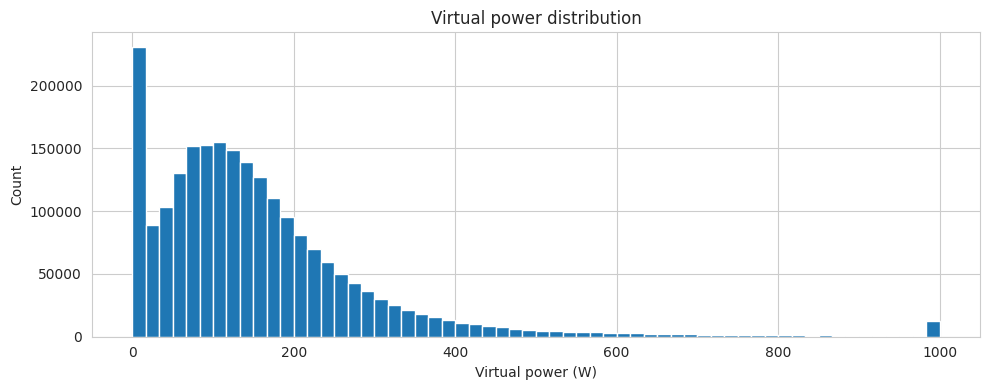

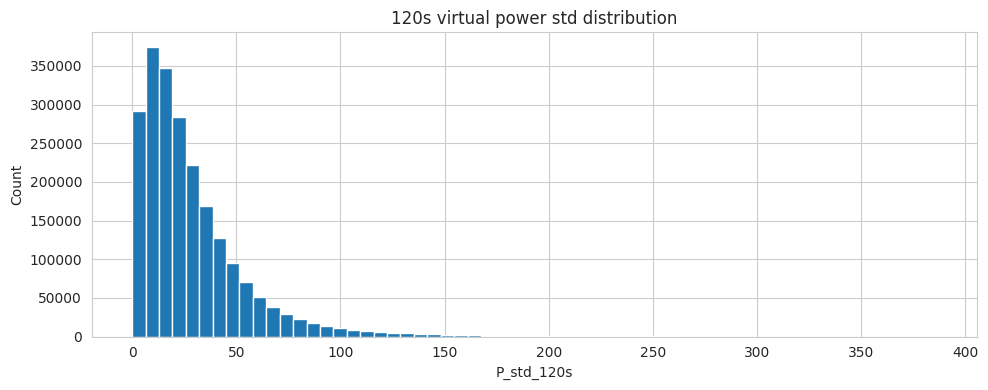

In [ ]:
# Cell 6 - sanity charts

plt.figure(figsize=(10,4))
plt.hist(df_feat["P_virtual"], bins=60)
plt.title("Virtual power distribution")
plt.xlabel("Virtual power (W)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_virtual_power_distribution.png", dpi=180)
plt.show()

plt.figure(figsize=(10,4))
plt.hist(df_feat["P_std_120s"].dropna(), bins=60)
plt.title("120s virtual power std distribution")
plt.xlabel("P_std_120s")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_pstd120_distribution.png", dpi=180)
plt.show()


/tmp/ipykernel_11475/3591360525.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df_feat.groupby("ride_id", group_keys=False).apply(add_steady_mask_per_ride).reset_index(drop=True)


            ride_id  steady_frac   steady_min  duration_min
count  3.535000e+03  3535.000000  3535.000000   3535.000000
mean   3.924843e+08     0.212310    11.168317     54.514003
std    1.540201e+08     0.254853    13.965141     13.535387
min    7.287917e+06     0.000000     0.000000     29.916667
25%    3.052081e+08     0.000000     0.000000     42.916667
50%    3.917809e+08     0.108802     5.250000     55.666667
75%    5.200558e+08     0.347263    17.666667     65.000000
max    6.675253e+08     0.993703    70.916667     82.916667
Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/02_features_steady_relaxed_v1.parquet


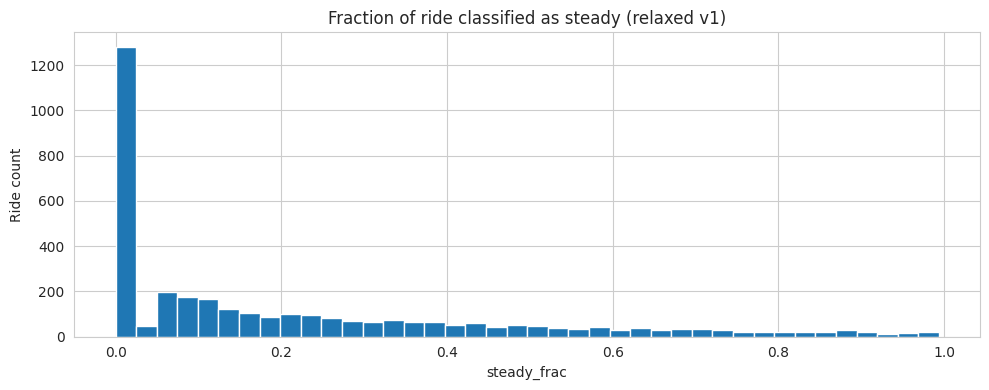

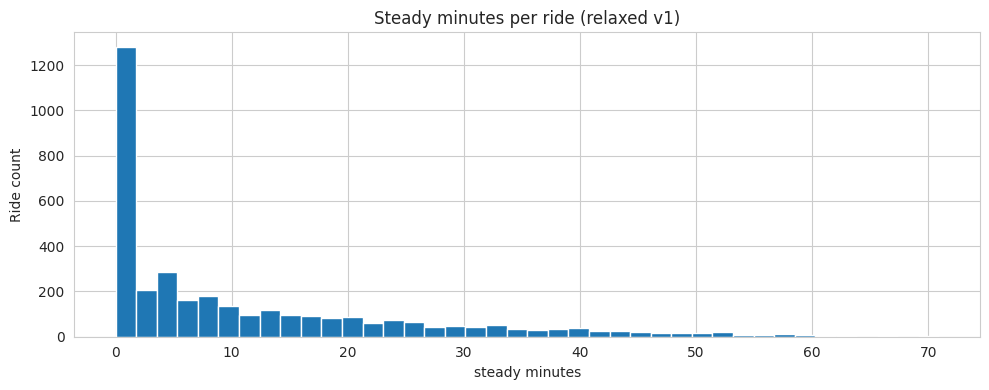

In [ ]:
# Cell 7 — Build steady-state mask

ON_N = int(CFG["debounce_on_sec"] / RESAMPLE_SECONDS)
OFF_N = int(CFG["debounce_off_sec"] / RESAMPLE_SECONDS)
HOLD_N = int(CFG["hold_gap_sec"] / RESAMPLE_SECONDS)
MIN_STEADY_N = int(CFG["min_steady_block_sec"] / RESAMPLE_SECONDS)

def add_steady_mask_per_ride(g):
    g = g.sort_values("elapsed_seconds").copy()

    raw = (
        (g["speed_kmh_clean"] >= CFG["min_speed_kmh"]) &
        (g["P_virtual_60s"] >= CFG["min_active_power"]) &
        (g["P_std_120s"] <= CFG["steady_pstd120_max"]) &
        (g["P_jump_5s"] <= CFG["steady_pjump5_max"]) &
        (g["grade_std_120s"] <= CFG["steady_grade_std120_max"]) &
        (g["speed_std_120s"] <= CFG["steady_speed_std120_max"])
    ).fillna(False).values

    steady = debounce_hold(raw, ON_N, OFF_N, HOLD_N)
    blocks = longest_true_blocks(steady)
    keep = np.zeros(len(g), dtype=bool)

    for s, e in blocks:
        if (e - s + 1) >= MIN_STEADY_N:
            keep[s:e+1] = True

    tss = np.zeros(len(g), dtype=float)
    for i in range(len(g)):
        tss[i] = (tss[i-1] + RESAMPLE_SECONDS) if (keep[i] and i > 0) else (RESAMPLE_SECONDS if keep[i] else 0.0)

    g["steady_raw"] = raw.astype(int)
    g["steady_final"] = keep.astype(int)
    g["tss_steady"] = tss
    return g

df_feat = df_feat.groupby("ride_id", group_keys=False).apply(add_steady_mask_per_ride).reset_index(drop=True)

steady_summary = df_feat.groupby("ride_id").agg(
    steady_frac=("steady_final","mean"),
    steady_min=("steady_final", lambda x: float(np.sum(np.asarray(x)==1) * RESAMPLE_SECONDS / 60.0)),
    duration_min=("elapsed_seconds", lambda x: float(np.max(x) / 60.0))
).reset_index()

print(steady_summary.describe())

save_ckpt(df_feat, "02_features_steady_relaxed_v1")
steady_summary.to_csv(f"{TAB_DIR}/steady_summary_relaxed_v1.csv", index=False)

plt.figure(figsize=(10,4))
plt.hist(steady_summary["steady_frac"], bins=40)
plt.title("Fraction of ride classified as steady (relaxed v1)")
plt.xlabel("steady_frac")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_steady_fraction_hist_relaxed_v1.png", dpi=180)
plt.show()

plt.figure(figsize=(10,4))
plt.hist(steady_summary["steady_min"], bins=40)
plt.title("Steady minutes per ride (relaxed v1)")
plt.xlabel("steady minutes")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_steady_minutes_hist_relaxed_v1.png", dpi=180)
plt.show()


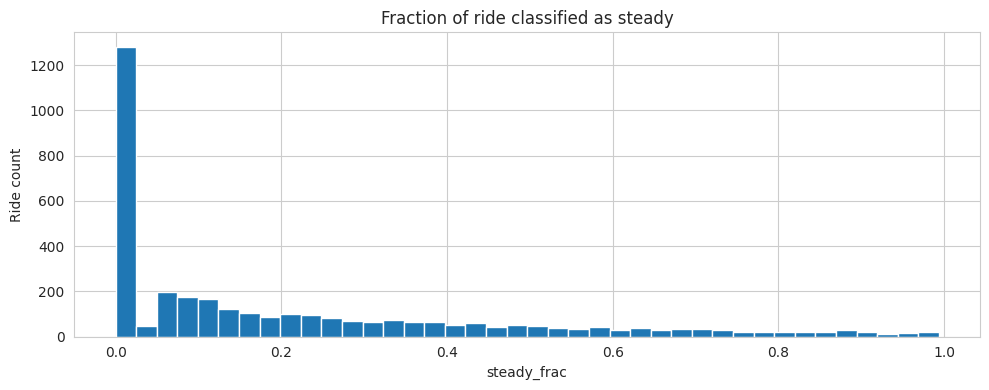

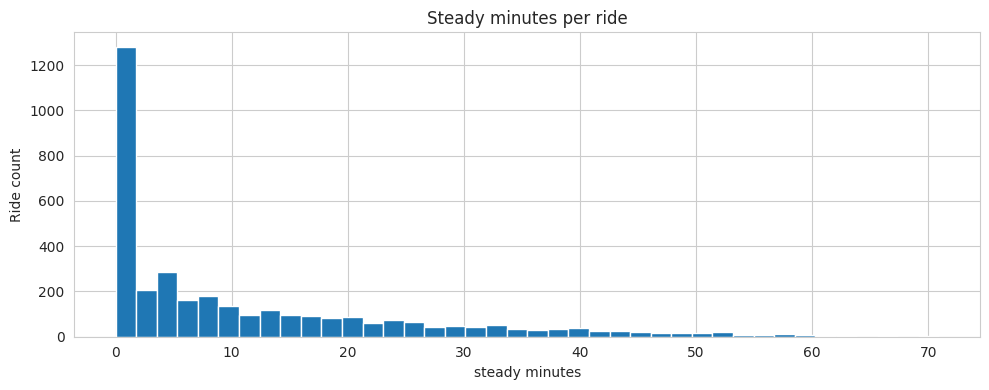

In [ ]:
# Cell 8 - Steady state charts

plt.figure(figsize=(10,4))
plt.hist(steady_summary["steady_frac"], bins=40)
plt.title("Fraction of ride classified as steady")
plt.xlabel("steady_frac")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_steady_fraction_hist.png", dpi=180)
plt.show()

plt.figure(figsize=(10,4))
plt.hist(steady_summary["steady_min"], bins=40)
plt.title("Steady minutes per ride")
plt.xlabel("steady minutes")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_steady_minutes_hist.png", dpi=180)
plt.show()


In [ ]:
# Cell 9 — Candidate model definitions

model_specs = {
    "ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "huber": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=600))
    ]),
    "gbr": GradientBoostingRegressor(
        n_estimators=140,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ),
    "rf": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=8,
        n_jobs=-1,
        random_state=42
    )
}

FEATURE_COLS = [
    "P_virtual_30s",
    "P_virtual_60s",
    "P_virtual_120s",
    "speed_kmh_clean",
    "grade_roll_120s"
]

print(model_specs.keys())


dict_keys(['ridge', 'huber', 'gbr', 'rf'])


In [ ]:
# Cell 10 — Expected HR model selection per ride

def fit_expected_hr_per_ride(g):
    g = g.sort_values("elapsed_seconds").copy()

    steady_mask = (
        (g["steady_final"] == 1) &
        (g["tss_steady"] >= CFG["min_steady_block_sec"]) &
        (g["speed_kmh_clean"] >= CFG["min_speed_kmh"])
    )

    idx = np.where(steady_mask.values)[0]
    if len(idx) == 0:
        fit_data = g[g["elapsed_seconds"] <= 900].copy()
    else:
        start_i = idx[0]
        start_sec = float(g["elapsed_seconds"].iloc[start_i])
        end_sec = start_sec + CFG["fit_window_sec"]
        fit_data = g[
            (g["elapsed_seconds"] >= start_sec) &
            (g["elapsed_seconds"] <= end_sec) &
            steady_mask
        ].copy()

    if len(fit_data) < CFG["min_fit_samples"]:
        fit_data = g[g["elapsed_seconds"] <= 900].copy()

    fit_data = fit_data.dropna(subset=FEATURE_COLS + ["hr"]).copy()

    if len(fit_data) < CFG["min_fit_samples"]:
        const = float(np.nanmedian(g["hr"]))
        g["hr_expected"] = const
        g["exp_model"] = "constant"
        g["fit_mae"] = np.nan
        return g

    fit_data = fit_data.sort_values("elapsed_seconds").reset_index(drop=True)
    n = len(fit_data)
    split = max(int(n * 0.7), CFG["min_fit_samples"] // 2)
    split = min(split, n - max(10, n // 5))

    train = fit_data.iloc[:split].copy()
    valid = fit_data.iloc[split:].copy()

    Xtr = train[FEATURE_COLS].values
    ytr = train["hr"].values
    Xva = valid[FEATURE_COLS].values
    yva = valid["hr"].values

    best_name, best_model, best_mae = None, None, np.inf

    for name, model in model_specs.items():
        try:
            model.fit(Xtr, ytr)
            pred = model.predict(Xva)
            mae = mean_absolute_error(yva, pred)
            if mae < best_mae:
                best_mae = mae
                best_name = name
                best_model = model
        except Exception:
            continue

    if best_model is None:
        const = float(np.nanmedian(g["hr"]))
        g["hr_expected"] = const
        g["exp_model"] = "constant"
        g["fit_mae"] = np.nan
        return g

    Xall = g[FEATURE_COLS].copy()
    train_ref = train[FEATURE_COLS]

    for c in FEATURE_COLS:
        lo = np.nanpercentile(train_ref[c], 1)
        hi = np.nanpercentile(train_ref[c], 99)
        margin = 0.10 * max(hi - lo, 1.0)
        Xall[c] = np.clip(Xall[c], lo - margin, hi + margin)

    yhat = best_model.predict(Xall.values)

    g["hr_expected"] = yhat
    g["exp_model"] = best_name
    g["fit_mae"] = best_mae
    return g

tqdm.pandas()
df_model = df_feat.groupby("ride_id", group_keys=False).progress_apply(fit_expected_hr_per_ride).reset_index(drop=True)

model_counts = df_model.groupby("ride_id")["exp_model"].first().value_counts()
print(model_counts)

save_ckpt(df_model, "03_expected_hr_relaxed_v1")
model_counts.to_csv(f"{TAB_DIR}/expected_model_counts_relaxed_v1.csv")


  0%|          | 0/3535 [00:00<?, ?it/s]

exp_model
rf       1001
gbr       994
ridge     803
huber     737
Name: count, dtype: int64
Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/03_expected_hr_relaxed_v1.parquet


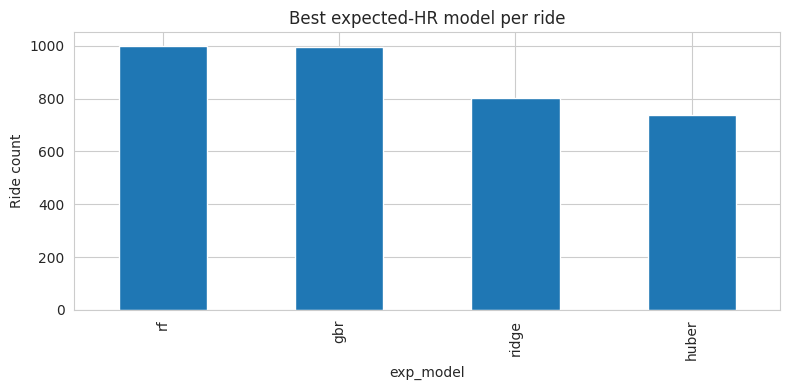

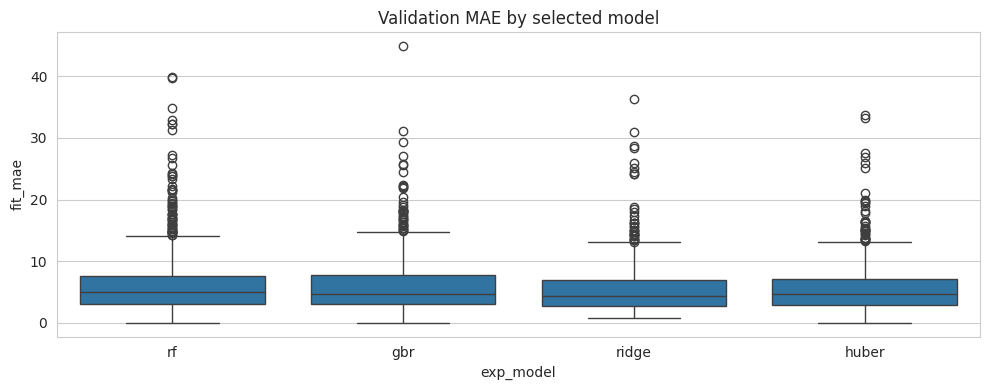

In [ ]:
# Cell 11 — Expected HR model summary charts

ride_model_summary = df_model.groupby("ride_id").agg(
    exp_model=("exp_model","first"),
    fit_mae=("fit_mae","first"),
    duration_min=("elapsed_seconds", lambda x: float(np.max(x) / 60.0))
).reset_index()

ride_model_summary.to_csv(f"{TAB_DIR}/ride_model_summary.csv", index=False)

plt.figure(figsize=(8,4))
ride_model_summary["exp_model"].value_counts().plot(kind="bar")
plt.title("Best expected-HR model per ride")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_best_model_counts.png", dpi=180)
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(data=ride_model_summary.dropna(subset=["fit_mae"]), x="exp_model", y="fit_mae")
plt.title("Validation MAE by selected model")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_model_fit_mae_boxplot.png", dpi=180)
plt.show()


/tmp/ipykernel_11475/3265008111.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ride_drift = df_model.groupby("ride_id").apply(lambda g: ride_level_drift_label(g)).reset_index()


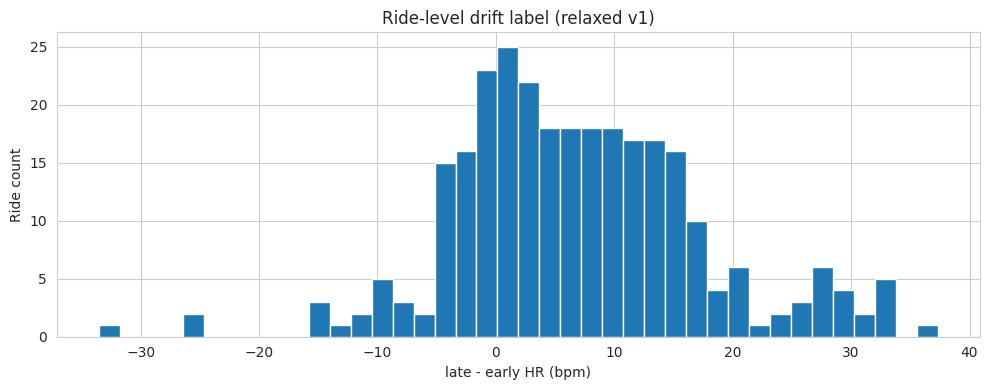

count    286.000000
mean       6.906680
std       10.600690
min      -33.524458
25%        0.110916
50%        6.291541
75%       13.020832
max       37.339092
Name: ride_drift_bpm, dtype: float64


In [ ]:
# Cell 12 — Ride-level descriptive drift label (for proof only)

def ride_level_drift_label(g, early_min=8, late_min=8):
    g = g.sort_values("elapsed_seconds").copy()
    gs = g[g["steady_final"] == 1].copy()

    if len(gs) < 2 * int(early_min * 60 / RESAMPLE_SECONDS):
        return np.nan

    early_sec = early_min * 60
    late_sec = late_min * 60
    tmax = float(gs["elapsed_seconds"].max())

    early = gs[gs["elapsed_seconds"] <= early_sec]
    late = gs[gs["elapsed_seconds"] >= (tmax - late_sec)]

    if len(early) < 15 or len(late) < 15:
        return np.nan

    p_early = float(early["P_virtual_60s"].mean())
    p_late = float(late["P_virtual_60s"].mean())

    if abs(p_late - p_early) > 25:
        return np.nan

    return float(late["hr"].mean() - early["hr"].mean())

ride_drift = df_model.groupby("ride_id").apply(lambda g: ride_level_drift_label(g)).reset_index()
ride_drift.columns = ["ride_id", "ride_drift_bpm"]
ride_drift.to_csv(f"{TAB_DIR}/ride_level_drift_labels_relaxed_v1.csv", index=False)

plt.figure(figsize=(10,4))
plt.hist(ride_drift["ride_drift_bpm"].dropna(), bins=40)
plt.title("Ride-level drift label (relaxed v1)")
plt.xlabel("late - early HR (bpm)")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_ride_level_drift_hist_relaxed_v1.png", dpi=180)
plt.show()

print(ride_drift["ride_drift_bpm"].describe())


In [ ]:
# Cell 13 — live-style drift estimator

DRIFT_START_SEC = CFG["drift_start_min"] * 60
POS_PERSIST_N = int(CFG["resid_persist_sec"] / RESAMPLE_SECONDS)

def estimate_drift_per_ride(g):
    g = g.sort_values("elapsed_seconds").copy()

    hr = g["hr"].astype(float).values
    exp = g["hr_expected"].astype(float).values
    resid = hr - exp
    t = g["elapsed_seconds"].astype(float).values

    corr_mask = (
        (g["steady_final"].values == 1) &
        (g["speed_kmh_clean"].values >= CFG["min_speed_kmh"]) &
        (g["P_virtual_60s"].values >= CFG["min_active_power"]) &
        (t >= DRIFT_START_SEC)
    )

    baseline_mask = (g["steady_final"].values == 1) & (t >= 5*60) & (t <= 12*60)
    baseline = float(np.nanmedian(resid[baseline_mask])) if np.any(baseline_mask) else 0.0
    resid_adj = resid - baseline

    drift = np.zeros(len(g), dtype=float)
    cur = 0.0
    pos_run = 0

    for i in range(len(g)):
        if corr_mask[i] and (resid_adj[i] >= CFG["resid_pos_thresh"]):
            pos_run += 1
        else:
            pos_run = 0
            if corr_mask[i]:
                cur *= CFG["drift_decay_on_steady"]

        if corr_mask[i] and (pos_run >= POS_PERSIST_N):
            cur = (1 - CFG["drift_alpha"]) * cur + CFG["drift_alpha"] * resid_adj[i]
            cur = np.clip(cur, 0.0, CFG["drift_clip_bpm"])

        drift[i] = cur

    hr_eff = hr.copy()
    hr_eff[corr_mask] = hr[corr_mask] - drift[corr_mask]

    g["residual"] = resid
    g["resid_adj"] = resid_adj
    g["drift_est"] = drift
    g["corr_active"] = corr_mask.astype(int)
    g["hr_effective"] = hr_eff
    g["drift_baseline"] = baseline
    return g

df_final = df_model.groupby("ride_id", group_keys=False).progress_apply(estimate_drift_per_ride).reset_index(drop=True)

save_ckpt(df_final, "04_final_with_drift_relaxed_v1")

end_drift = df_final.groupby("ride_id")["drift_est"].tail(1).reset_index(drop=True)
print(end_drift.describe())
print("Fraction >= 15 bpm:", float(np.mean(end_drift >= 15.0)))


  0%|          | 0/3535 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/checkpoints/04_final_with_drift_relaxed_v1.parquet
count    3535.000000
mean        2.895216
std         4.524960
min         0.000000
25%         0.000000
50%         0.090681
75%         4.256385
max        15.000000
Name: drift_est, dtype: float64
Fraction >= 15 bpm: 0.04328147100424328


In [ ]:
# Export app assets

import os
import json
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor

os.makedirs(MODEL_DIR, exist_ok=True)

# 1) Export drift_params.json
drift_params_app = {
    "RESAMPLE_SECONDS": int(RESAMPLE_SECONDS),
    "EWMA_ALPHA": float(CFG["drift_alpha"]),
    "DRIFT_CLIP_BPM": float(CFG["drift_clip_bpm"]),
    "POS_RESID_THRESH": float(CFG["resid_pos_thresh"]),
    "POS_PERSIST_SEC": int(CFG["resid_persist_sec"]),
    "P_STD_MAX_60S": float(CFG["steady_pstd120_max"]),
    "P_JUMP_MAX_5S": float(CFG["steady_pjump5_max"]),
    "P_MIN_ACTIVE": float(CFG["min_active_power"]),
    "SPEED_MIN_ACTIVE": float(CFG["min_speed_kmh"]),
    "DRIFT_DECAY": float(CFG["drift_decay_on_steady"]),
    "BASELINE_MIN": 8,
    "MIN_STEADY_POWER_SEC": int(CFG["min_steady_block_sec"]),
    "CALIB_MIN_SESSION": 12,
    "DRIFT_START_MIN": int(CFG["drift_start_min"]),
    "DRIFT_MAX_CHANGE_BPM_PER_MIN": 3.0
}

drift_params_path = f"{MODEL_DIR}/drift_params.json"
with open(drift_params_path, "w") as f:
    json.dump(drift_params_app, f, indent=2)

print("Saved:", drift_params_path)

# 2) Exportexpected_hr_global.json
feature_map_candidates = {
    "P_used_roll_60s": ["P_virtual_60s", "Pusedroll60s", "P_used_roll_60s"],
    "P_used": ["P_virtual", "Pused", "P_used"],
    "speed_kmh_clean": ["speed_kmh_clean", "speedkmhclean"],
    "grade_roll_2m": ["grade_roll_120s", "graderoll120s", "grade_roll_2m"],
}

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_p60 = pick_col(df_model, feature_map_candidates["P_used_roll_60s"])
col_p   = pick_col(df_model, feature_map_candidates["P_used"])
col_sp  = pick_col(df_model, feature_map_candidates["speed_kmh_clean"])
col_gr  = pick_col(df_model, feature_map_candidates["grade_roll_2m"])

chosen = [col_p60, col_p, col_sp, col_gr]
print("Chosen columns:", chosen)

if any(c is None for c in chosen):
    raise ValueError(f"Missing one or more required columns for app export: {chosen}")

fit_df = df_model[[col_p60, col_p, col_sp, col_gr, "hr"]].dropna().copy()

X = fit_df[[col_p60, col_p, col_sp, col_gr]].astype(float).values
y = fit_df["hr"].astype(float).values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=600))
])

pipe.fit(X, y)

scaler = pipe.named_steps["scaler"]
model = pipe.named_steps["model"]

expected_hr_global = {
    "feat_cols": ["P_used_roll_60s", "P_used", "speed_kmh_clean", "grade_roll_2m"],
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "intercept": float(model.intercept_),
    "coef": model.coef_.tolist(),
    "model_type": "huber_global_app"
}

weights_path = f"{MODEL_DIR}/expected_hr_global.json"
with open(weights_path, "w") as f:
    json.dump(expected_hr_global, f, indent=2)

print("Saved:", weights_path)
print("Done.")

Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/models/drift_params.json
Chosen columns: ['P_virtual_60s', 'P_virtual', 'speed_kmh_clean', 'grade_roll_120s']
Saved: /content/drive/MyDrive/hr_zone_rebuild_v1/models/expected_hr_global.json
Done.


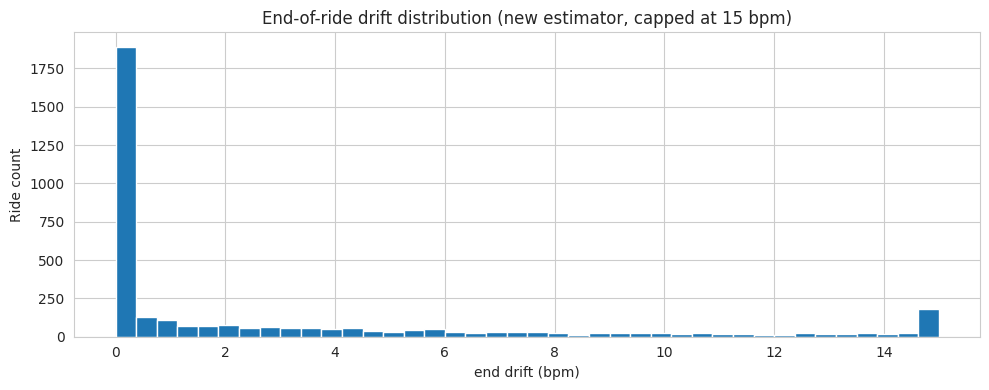

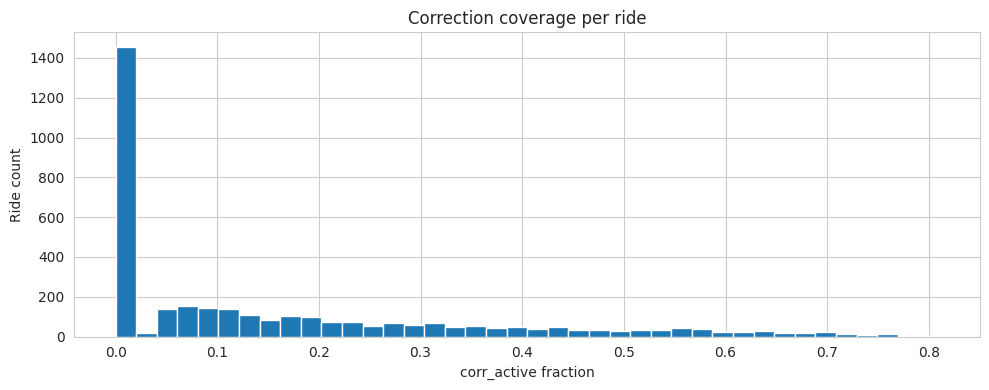

In [ ]:
# Cell 14 - Drift charts

corr_frac = df_final.groupby("ride_id")["corr_active"].mean().reset_index(name="corr_frac")
end_drift = df_final.groupby("ride_id")["drift_est"].tail(1).reset_index(drop=True)

plt.figure(figsize=(10,4))
plt.hist(end_drift, bins=40)
plt.title("End-of-ride drift distribution (new estimator, capped at 15 bpm)")
plt.xlabel("end drift (bpm)")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_end_drift_hist_new.png", dpi=180)
plt.show()

plt.figure(figsize=(10,4))
plt.hist(corr_frac["corr_frac"], bins=40)
plt.title("Correction coverage per ride")
plt.xlabel("corr_active fraction")
plt.ylabel("Ride count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_corr_fraction_hist_new.png", dpi=180)
plt.show()

corr_frac.to_csv(f"{TAB_DIR}/corr_fraction_per_ride.csv", index=False)


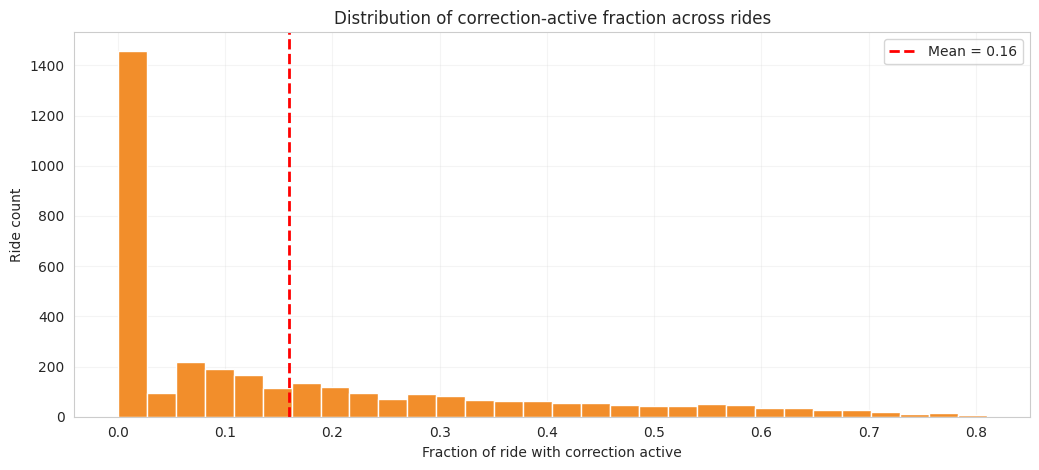

In [ ]:
# Cell 14b — Correction-active fraction across rides

ride_corr = (
    df_final.groupby("ride_id")["corr_active"]
    .mean()
    .reset_index(name="corr_frac")
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.hist(ride_corr["corr_frac"], bins=30, color="#f28e2b", edgecolor="white")
ax.axvline(ride_corr["corr_frac"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {ride_corr['corr_frac'].mean():.2f}")

ax.set_title("Distribution of correction-active fraction across rides")
ax.set_xlabel("Fraction of ride with correction active")
ax.set_ylabel("Ride count")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14b_corr_fraction_distribution.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 15 — Main evaluation which is fixed for late-start drift correction

BASE_START_SEC = 5 * 60
BASE_END_SEC   = 12 * 60
LATE_SEC       = 8 * 60
MIN_BASE_SAMPLES = 15
MIN_LATE_SAMPLES = 15

rows = []

for rid, g in tqdm(df_final.groupby("ride_id"), total=df_final["ride_id"].nunique()):
    g = g.sort_values("elapsed_seconds").copy()

    base = g[
        (g["steady_final"] == 1) &
        (g["elapsed_seconds"] >= BASE_START_SEC) &
        (g["elapsed_seconds"] <= BASE_END_SEC)
    ].copy()

    corr = g[g["corr_active"] == 1].copy()
    if len(corr) < MIN_LATE_SAMPLES:
        continue

    tmax_corr = float(corr["elapsed_seconds"].max())
    late = corr[corr["elapsed_seconds"] >= (tmax_corr - LATE_SEC)].copy()

    if len(base) < MIN_BASE_SAMPLES or len(late) < MIN_LATE_SAMPLES:
        continue

    rows.append({
        "ride_id": rid,
        "exp_model": g["exp_model"].iloc[0],
        "baseline_steady_min": float(len(base) * RESAMPLE_SECONDS / 60.0),
        "corrected_steady_min": float(len(corr) * RESAMPLE_SECONDS / 60.0),
        "mae_base_obs": float(mean_absolute_error(base["hr"], base["hr_expected"])),
        "mae_late_obs": float(mean_absolute_error(late["hr"], late["hr_expected"])),
        "mae_late_eff": float(mean_absolute_error(late["hr_effective"], late["hr_expected"])),
        "mean_drift_corr": float(corr["drift_est"].mean()),
        "end_drift": float(corr["drift_est"].iloc[-1]),
        "n_base": int(len(base)),
        "n_late": int(len(late))
    })

eval_df = pd.DataFrame(rows)

if len(eval_df) == 0:
    print("No rides passed evaluation filters.")
else:
    eval_df["late_improvement"] = eval_df["mae_late_obs"] - eval_df["mae_late_eff"]
    eval_df.to_csv(f"{TAB_DIR}/main_evaluation_relaxed_v2.csv", index=False)

    print("Evaluation rides:", len(eval_df))
    print(eval_df[[
        "mae_base_obs","mae_late_obs","mae_late_eff",
        "late_improvement","mean_drift_corr","end_drift","n_base","n_late"
    ]].describe())
    print("Pct improved:", float((eval_df["late_improvement"] > 0).mean() * 100.0))


  0%|          | 0/3535 [00:00<?, ?it/s]

Evaluation rides: 1008
       mae_base_obs  mae_late_obs  mae_late_eff  late_improvement  \
count  1.008000e+03   1008.000000   1008.000000       1008.000000   
mean   2.893595e+00      9.682976      7.343589          2.339387   
std    2.532763e+00      8.204951      6.598927          4.995166   
min    1.421085e-14      0.948778      0.901626        -11.720869   
25%    1.325450e+00      4.172102      3.296065         -0.259052   
50%    2.219131e+00      7.141141      5.338853          0.165349   
75%    3.670015e+00     12.395499      8.829989          4.736166   
max    2.725955e+01     68.653786     73.444682         15.000000   

       mean_drift_corr    end_drift       n_base       n_late  
count      1008.000000  1008.000000  1008.000000  1008.000000  
mean          3.914918     5.718770    57.571429    73.726190  
std           3.789035     5.173531    21.766451    21.931246  
min           0.000000     0.000000    15.000000    19.000000  
25%           0.683940     1.013156

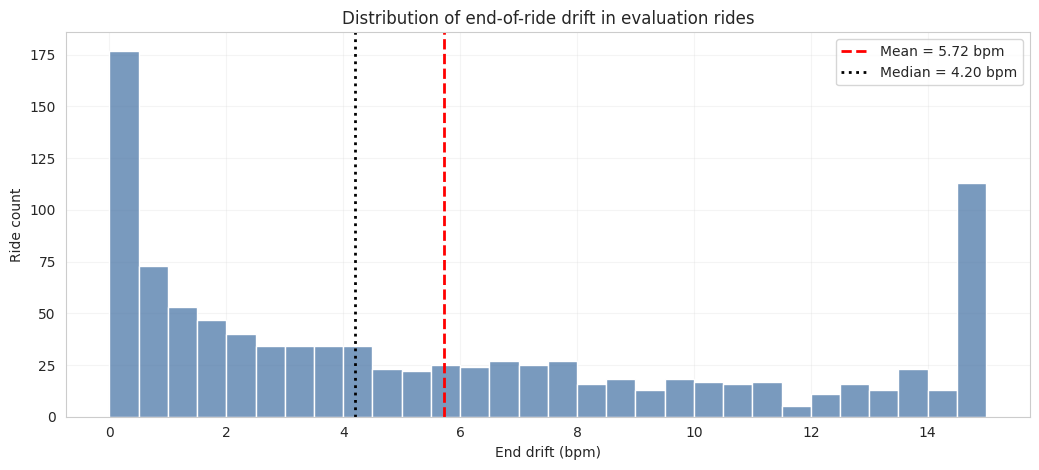

In [ ]:
# Cell 15a — End-drift distribution across all rides

import seaborn as sns

fig, ax = plt.subplots(figsize=(10.5, 4.8))
sns.histplot(eval_df["end_drift"], bins=30, kde=False, color="#4c78a8", ax=ax)

mean_d = eval_df["end_drift"].mean()
med_d = eval_df["end_drift"].median()

ax.axvline(mean_d, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_d:.2f} bpm")
ax.axvline(med_d, color="black", linestyle=":", linewidth=2, label=f"Median = {med_d:.2f} bpm")

ax.set_title("Distribution of end-of-ride drift in evaluation rides")
ax.set_xlabel("End drift (bpm)")
ax.set_ylabel("Ride count")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20b_end_drift_distribution_eval.png", dpi=180, bbox_inches="tight")
plt.show()


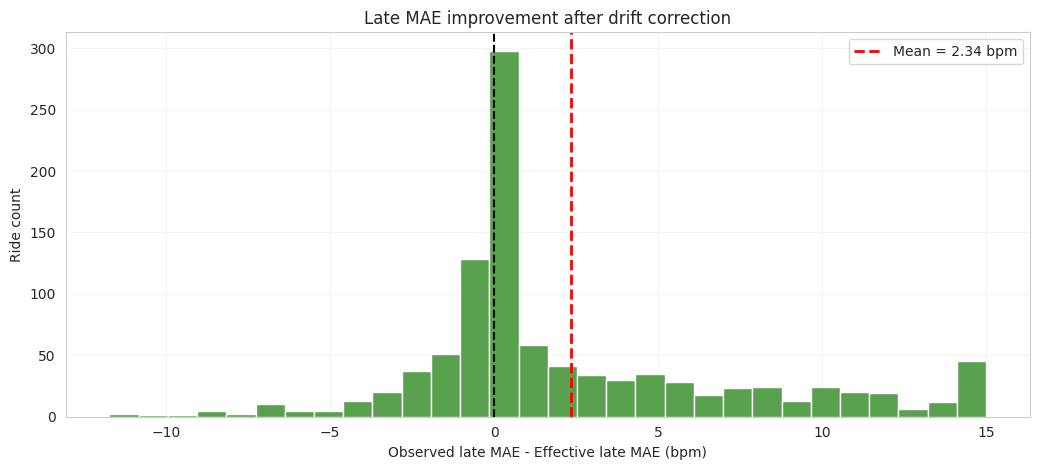

In [ ]:
# Cell 15b — Histogram of late MAE improvement

fig, ax = plt.subplots(figsize=(10.5, 4.8))
impr = eval_df["late_improvement"]

ax.hist(impr, bins=30, color="#59a14f", edgecolor="white")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
ax.axvline(impr.mean(), color="red", linewidth=2, linestyle="--", label=f"Mean = {impr.mean():.2f} bpm")

ax.set_title("Late MAE improvement after drift correction")
ax.set_xlabel("Observed late MAE - Effective late MAE (bpm)")
ax.set_ylabel("Ride count")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20c_late_mae_improvement_hist.png", dpi=180, bbox_inches="tight")
plt.show()


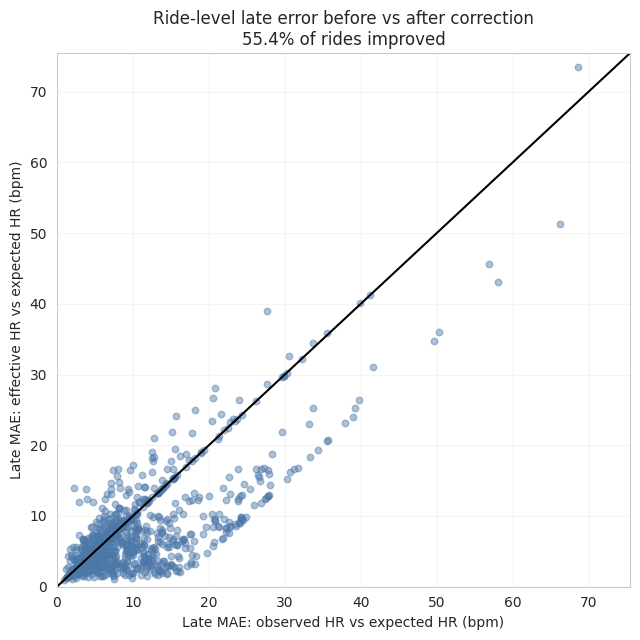

In [ ]:
# Cell 15c — Late MAE scatter: observed vs effective

fig, ax = plt.subplots(figsize=(6.5, 6.5))

x = eval_df["mae_late_obs"]
y = eval_df["mae_late_eff"]
pct_improved = (y < x).mean() * 100

ax.scatter(x, y, alpha=0.45, s=22, color="#4c78a8")
m = max(x.max(), y.max()) + 2
ax.plot([0, m], [0, m], color="black", linewidth=1.5)

ax.set_xlim(0, m)
ax.set_ylim(0, m)
ax.set_xlabel("Late MAE: observed HR vs expected HR (bpm)")
ax.set_ylabel("Late MAE: effective HR vs expected HR (bpm)")
ax.set_title(f"Ride-level late error before vs after correction\n{pct_improved:.1f}% of rides improved")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20d_late_mae_scatter.png", dpi=180, bbox_inches="tight")
plt.show()


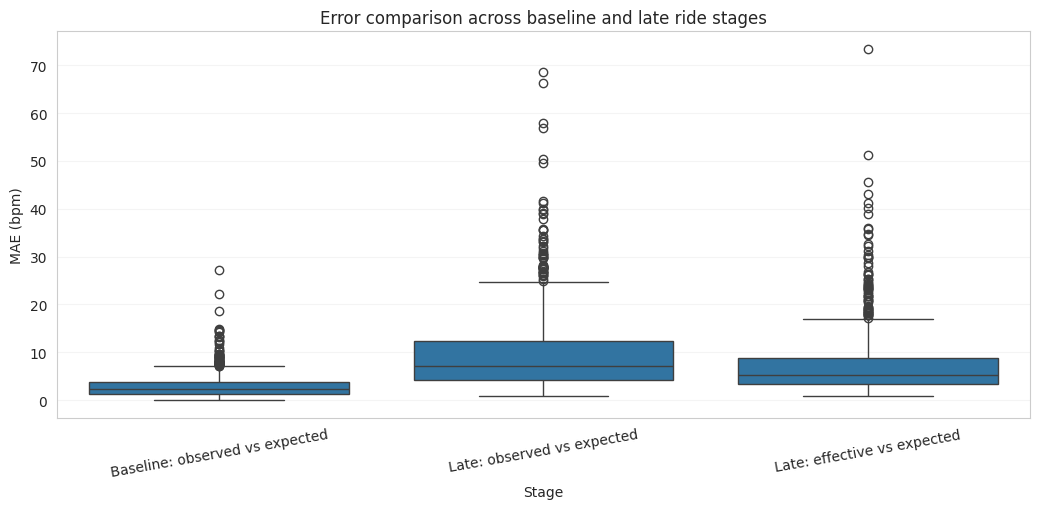

In [ ]:
# Cell 15d — Baseline vs late MAE comparison

plot_df = pd.DataFrame({
    "MAE (bpm)": np.concatenate([
        eval_df["mae_base_obs"].values,
        eval_df["mae_late_obs"].values,
        eval_df["mae_late_eff"].values
    ]),
    "Stage": (
        ["Baseline: observed vs expected"] * len(eval_df) +
        ["Late: observed vs expected"] * len(eval_df) +
        ["Late: effective vs expected"] * len(eval_df)
    )
})

fig, ax = plt.subplots(figsize=(10.5, 5.2))
sns.boxplot(data=plot_df, x="Stage", y="MAE (bpm)", ax=ax)
ax.set_title("Error comparison across baseline and late ride stages")
ax.grid(True, axis="y", alpha=0.2)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20g_mae_stage_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()


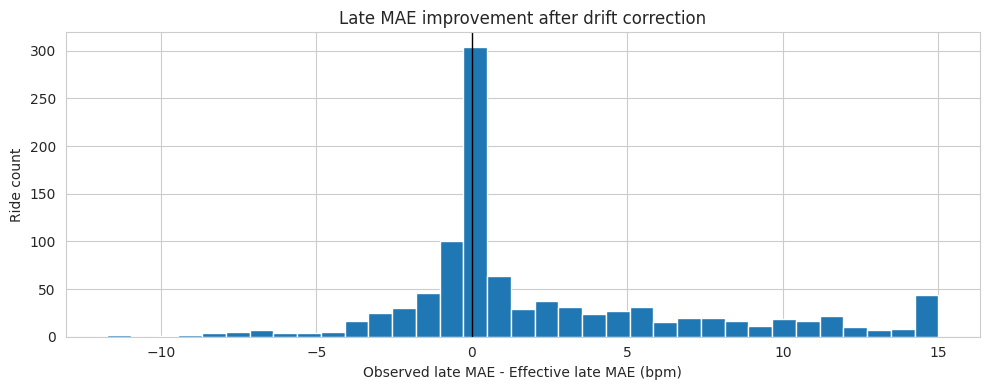

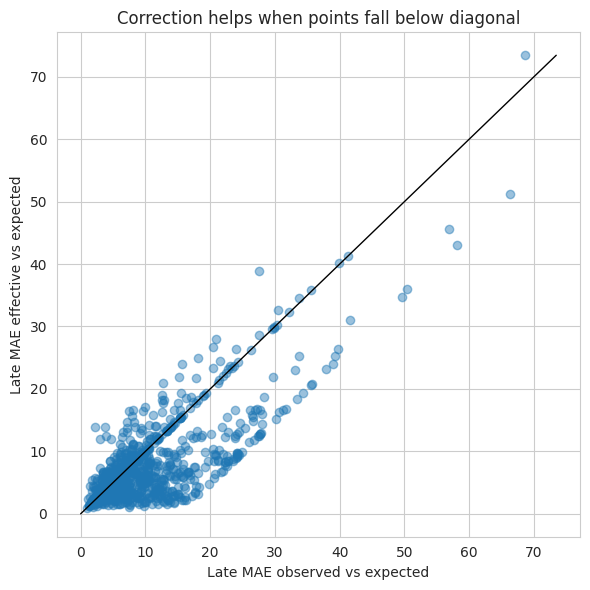

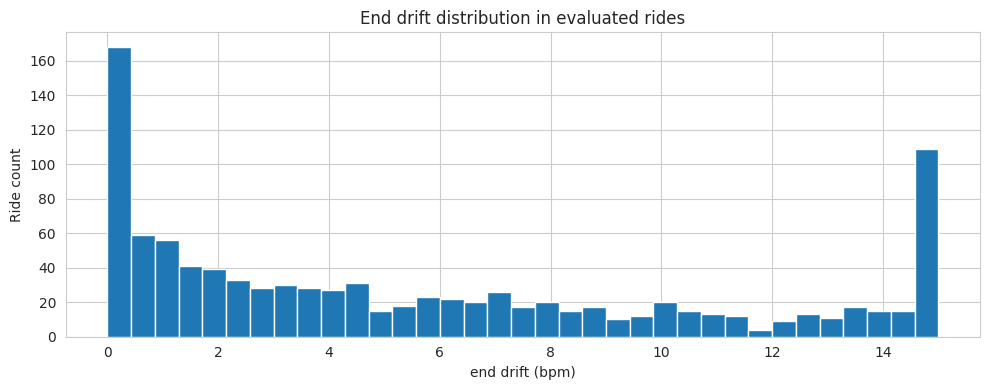

In [ ]:
# Cell 16 — Main report charts

if len(eval_df) > 0:
    plt.figure(figsize=(10,4))
    plt.hist(eval_df["late_improvement"], bins=35)
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Late MAE improvement after drift correction")
    plt.xlabel("Observed late MAE - Effective late MAE (bpm)")
    plt.ylabel("Ride count")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/10_late_mae_improvement_hist_relaxed_v2.png", dpi=180)
    plt.show()

    plt.figure(figsize=(6,6))
    plt.scatter(eval_df["mae_late_obs"], eval_df["mae_late_eff"], alpha=0.45)
    mx = float(max(eval_df["mae_late_obs"].max(), eval_df["mae_late_eff"].max()))
    plt.plot([0, mx], [0, mx], color="black", linewidth=1)
    plt.xlabel("Late MAE observed vs expected")
    plt.ylabel("Late MAE effective vs expected")
    plt.title("Correction helps when points fall below diagonal")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/11_late_mae_scatter_relaxed_v2.png", dpi=180)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.hist(eval_df["end_drift"], bins=35)
    plt.title("End drift distribution in evaluated rides")
    plt.xlabel("end drift (bpm)")
    plt.ylabel("Ride count")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/12_eval_end_drift_hist_relaxed_v2.png", dpi=180)
    plt.show()
else:
    print("Skipping Cell 16 charts because eval_df is empty.")


In [ ]:
# Cell 17 — Summary table for thesis

summary_rows = [
    {"Metric": "Total rides", "Value": int(df_final["ride_id"].nunique())},
    {"Metric": "Cyclists", "Value": int(df_final["cyclist_id"].nunique())},
    {"Metric": "Mean end drift all rides", "Value": float(end_drift.mean())},
    {"Metric": "Median end drift all rides", "Value": float(np.median(end_drift))},
    {"Metric": "Max end drift all rides", "Value": float(np.max(end_drift))},
    {"Metric": "Fraction rides at 15 bpm cap (%)", "Value": float(np.mean(end_drift >= 15.0) * 100.0)},
]

if len(eval_df) > 0:
    summary_rows += [
        {"Metric": "Evaluation rides", "Value": int(len(eval_df))},
        {"Metric": "Mean baseline MAE (obs vs exp)", "Value": float(eval_df["mae_base_obs"].mean())},
        {"Metric": "Mean late MAE (obs vs exp)", "Value": float(eval_df["mae_late_obs"].mean())},
        {"Metric": "Mean late MAE (eff vs exp)", "Value": float(eval_df["mae_late_eff"].mean())},
        {"Metric": "Pct rides improved late", "Value": float((eval_df["late_improvement"] > 0).mean() * 100.0)},
        {"Metric": "Mean drift over corrected segments", "Value": float(eval_df["mean_drift_corr"].mean())},
    ]

summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(f"{TAB_DIR}/thesis_summary_table_relaxed_v2.csv", index=False)
print(summary_table.to_markdown(index=False))


| Metric                             |        Value |
|:-----------------------------------|-------------:|
| Total rides                        | 3535         |
| Cyclists                           |  422         |
| Mean end drift all rides           |    2.89522   |
| Median end drift all rides         |    0.0906814 |
| Max end drift all rides            |   15         |
| Fraction rides at 15 bpm cap (%)   |    4.32815   |
| Evaluation rides                   | 1008         |
| Mean baseline MAE (obs vs exp)     |    2.8936    |
| Mean late MAE (obs vs exp)         |    9.68298   |
| Mean late MAE (eff vs exp)         |    7.34359   |
| Pct rides improved late            |   55.3571    |
| Mean drift over corrected segments |    3.91492   |


In [ ]:
# Cell 17a — Dataset composition summary table

dataset_summary = pd.DataFrame({
    "Metric": [
        "Total rides",
        "Unique cyclists",
        "Total synchronized samples",
        "Sampling interval (seconds)",
        "Minimum ride duration (minutes)",
        "Maximum ride duration (minutes)",
        "Median rides per cyclist"
    ],
    "Value": [
        int(df_final["ride_id"].nunique()),
        int(df_final["cyclist_id"].nunique()),
        int(len(df_final)),
        5,
        round(df_final.groupby("ride_id")["elapsed_seconds"].max().min() / 60.0, 2),
        round(df_final.groupby("ride_id")["elapsed_seconds"].max().max() / 60.0, 2),
        float(df_final.groupby("cyclist_id")["ride_id"].nunique().median())
    ]
})

display(dataset_summary)
dataset_summary.to_csv(f"{FIG_DIR}/20a_dataset_summary_table.csv", index=False)


,Metric,Value
0,Total rides,3535.00
1,Unique cyclists,422.00
2,Total synchronized samples,2213504.00
3,Sampling interval (seconds),5.00
4,Minimum ride duration (minutes),29.92
5,Maximum ride duration (minutes),82.92
6,Median rides per cyclist,5.00


In [ ]:
# Cell 17b — Key evaluation results table

key_results = pd.DataFrame({
    "Metric": [
        "Total rides",
        "Cyclists",
        "Evaluation rides",
        "Mean baseline MAE (observed vs expected)",
        "Mean late MAE (observed vs expected)",
        "Mean late MAE (effective vs expected)",
        "Mean late improvement",
        "Percentage of rides improved",
        "Mean drift over corrected segments",
        "Mean end drift in evaluation rides",
        "Maximum end drift in evaluation rides"
    ],
    "Value": [
        int(df_final["ride_id"].nunique()),
        int(df_final["cyclist_id"].nunique()),
        int(len(eval_df)),
        round(eval_df["mae_base_obs"].mean(), 2),
        round(eval_df["mae_late_obs"].mean(), 2),
        round(eval_df["mae_late_eff"].mean(), 2),
        round(eval_df["late_improvement"].mean(), 2),
        round((eval_df["late_improvement"] > 0).mean() * 100, 2),
        round(eval_df["mean_drift_corr"].mean(), 2),
        round(eval_df["end_drift"].mean(), 2),
        round(eval_df["end_drift"].max(), 2)
    ]
})

display(key_results)
key_results.to_csv(f"{TAB_DIR}/20a_key_evaluation_results.csv", index=False)


,Metric,Value
0,Total rides,3535.00
1,Cyclists,422.00
2,Evaluation rides,1008.00
3,Mean baseline MAE (observed vs expected),2.89
4,Mean late MAE (observed vs expected),9.68
5,Mean late MAE (effective vs expected),7.34
6,Mean late improvement,2.34
7,Percentage of rides improved,55.36
8,Mean drift over corrected segments,3.91
9,Mean end drift in evaluation rides,5.72


In [ ]:
# Cell 18 — Selects best demo ride

demo_pool = eval_df.copy()

demo_pool = demo_pool[
    (demo_pool["late_improvement"] > 1.0) &
    (demo_pool["mae_late_eff"] < demo_pool["mae_late_obs"]) &
    (demo_pool["mae_base_obs"] <= 6.0) &
    (demo_pool["end_drift"] >= 3.0) &
    (demo_pool["end_drift"] <= 10.0)
].copy()

ride_demo_stats = df_final.groupby("ride_id").agg(
    duration_min=("elapsed_seconds", lambda x: float(np.max(x) / 60.0)),
    corr_frac=("corr_active","mean"),
    exp_model=("exp_model","first"),
    hr_min=("hr","min"),
    hr_max=("hr","max")
).reset_index()

demo_pool = demo_pool.merge(ride_demo_stats, on="ride_id", how="left")

demo_pool = demo_pool[
    (demo_pool["duration_min"] >= 45.0) &
    (demo_pool["corr_frac"] >= 0.20) &
    (demo_pool["corr_frac"] <= 0.65)
].copy()

demo_pool = demo_pool.sort_values(
    ["late_improvement", "mae_base_obs", "end_drift"],
    ascending=[False, True, True]
).reset_index(drop=True)

print(demo_pool.head(10))

if len(demo_pool) == 0:
    print("No ideal demo ride found; falling back to best positive-improvement ride.")
    demo_pool = eval_df.merge(ride_demo_stats, on="ride_id", how="left")
    demo_pool = demo_pool.sort_values(
        ["late_improvement", "mae_base_obs"],
        ascending=[False, True]
    ).reset_index(drop=True)

DEMO_RIDE_ID = int(demo_pool.iloc[0]["ride_id"])
print("Selected demo ride:", DEMO_RIDE_ID)


     ride_id exp_model_x  baseline_steady_min  corrected_steady_min  \
0  536416387         gbr             6.333333             19.583333   
1  213490439       ridge             3.750000             13.166667   
2  611101951       ridge             4.666667             25.583333   
3  209877970          rf             4.666667             15.083333   
4  303654263         gbr             7.083333             25.666667   
5  322879179         gbr             7.083333             20.583333   
6  326679258          rf             2.666667             21.166667   
7  192635530       huber             7.083333             31.666667   
8  332283603          rf             7.083333             26.250000   
9  221498090          rf             7.083333             35.333333   

   mae_base_obs  mae_late_obs  mae_late_eff  mean_drift_corr  end_drift  \
0      1.455033      9.846772      1.173421         6.809129   9.449323   
1      2.250246     12.866240      5.403021         4.778629   9.864

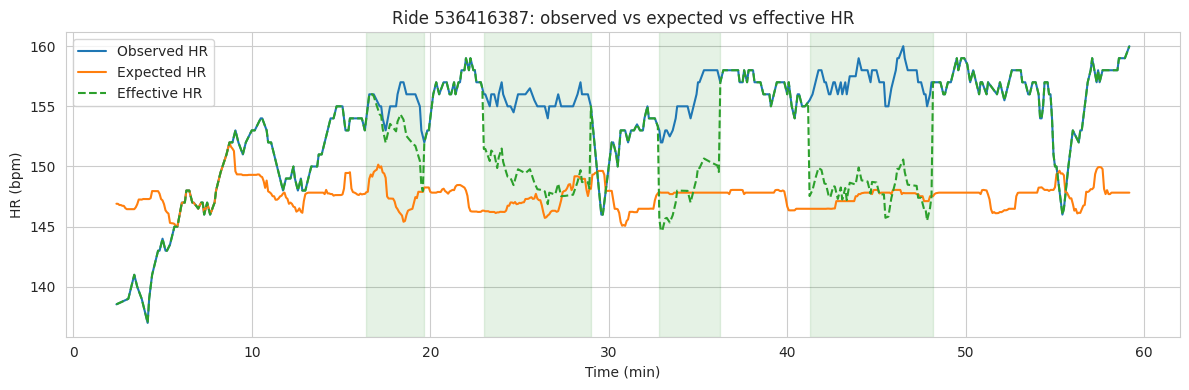

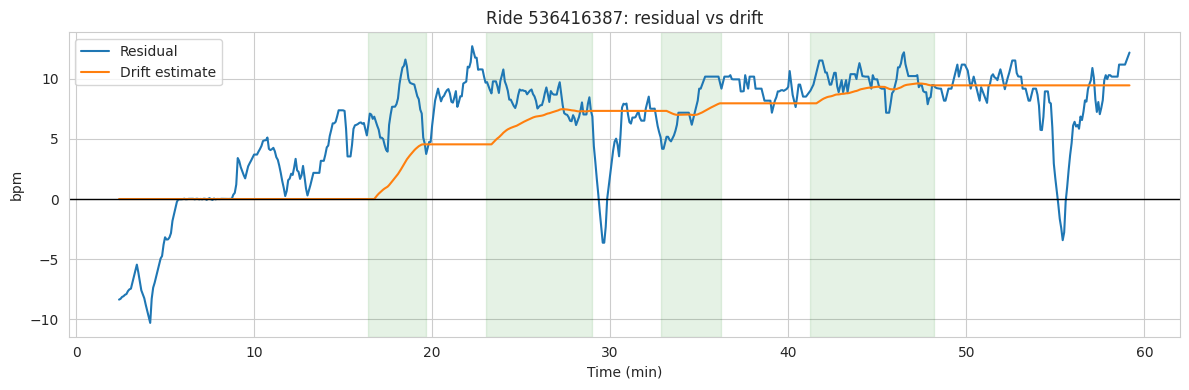

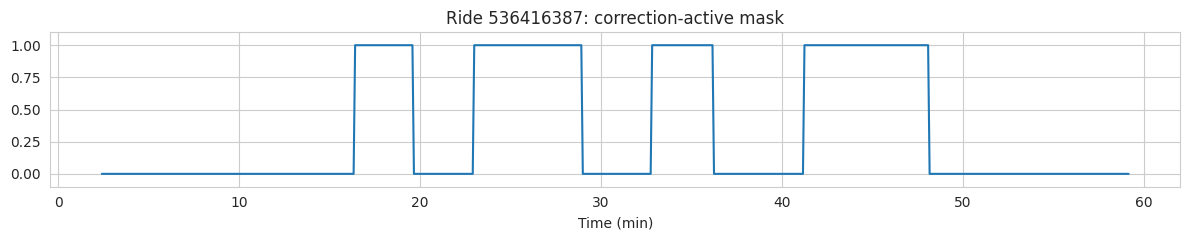

In [ ]:
# Cell 19 — Demo ride plots adn export for app


r = df_final[df_final["ride_id"] == DEMO_RIDE_ID].sort_values("elapsed_seconds").copy()
x = r["elapsed_seconds"].values / 60.0
corr = r["corr_active"].values.astype(int)

def shade_corr_regions(ax, xvals, mask):
    in_block = False
    start = None
    for i, v in enumerate(mask):
        if v == 1 and not in_block:
            start = xvals[i]
            in_block = True
        if v == 0 and in_block:
            ax.axvspan(start, xvals[i], color="green", alpha=0.10)
            in_block = False
    if in_block:
        ax.axvspan(start, xvals[-1], color="green", alpha=0.10)

plt.figure(figsize=(12,4))
ax = plt.gca()
plt.plot(x, r["hr"], label="Observed HR")
plt.plot(x, r["hr_expected"], label="Expected HR")
plt.plot(x, r["hr_effective"], label="Effective HR", linestyle="--")
shade_corr_regions(ax, x, corr)
plt.xlabel("Time (min)")
plt.ylabel("HR (bpm)")
plt.title(f"Ride {DEMO_RIDE_ID}: observed vs expected vs effective HR")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_demo_hr_overlay_shaded.png", dpi=180)
plt.show()

plt.figure(figsize=(12,4))
ax = plt.gca()
plt.plot(x, r["residual"], label="Residual")
plt.plot(x, r["drift_est"], label="Drift estimate")
plt.axhline(0, color="black", linewidth=1)
shade_corr_regions(ax, x, corr)
plt.xlabel("Time (min)")
plt.ylabel("bpm")
plt.title(f"Ride {DEMO_RIDE_ID}: residual vs drift")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_demo_residual_drift_shaded.png", dpi=180)
plt.show()

plt.figure(figsize=(12,2.5))
plt.plot(x, r["corr_active"], label="corr_active")
plt.ylim(-0.1, 1.1)
plt.xlabel("Time (min)")
plt.title(f"Ride {DEMO_RIDE_ID}: correction-active mask")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/15_demo_corr_mask_shaded.png", dpi=180)
plt.show()


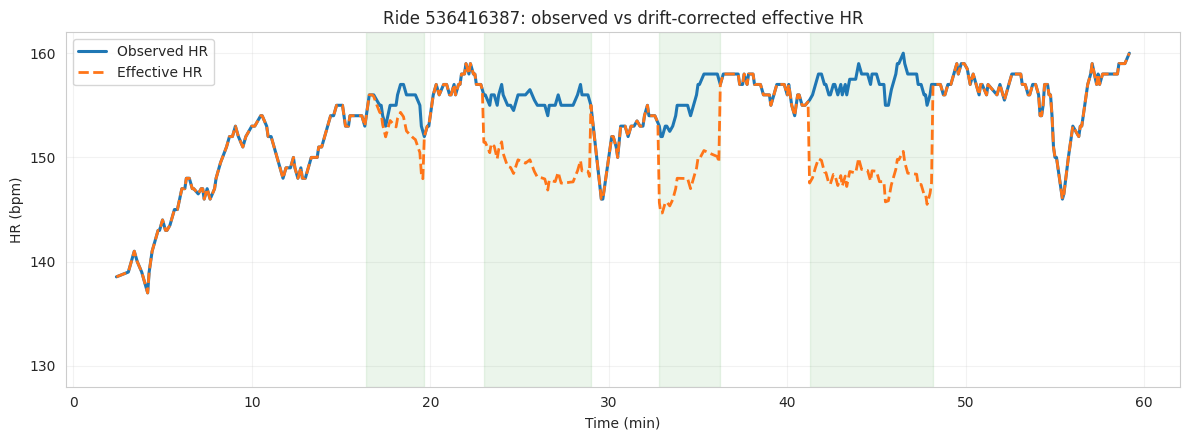

In [ ]:
# Cell 19a — Demo ride chart of observed vs effective only

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

r = df_final[df_final["ride_id"] == DEMO_RIDE_ID].sort_values("elapsed_seconds").copy()
x = r["elapsed_seconds"].values / 60.0
corr = r["corr_active"].fillna(0).astype(int).values

def shade_corr_regions(ax, xvals, mask, color="green", alpha=0.10):
    in_block = False
    start = None
    for i, v in enumerate(mask):
        if v == 1 and not in_block:
            start = xvals[i]
            in_block = True
        elif v == 0 and in_block:
            ax.axvspan(start, xvals[i], color=color, alpha=alpha)
            in_block = False
    if in_block:
        ax.axvspan(start, xvals[-1], color=color, alpha=alpha)

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(x, r["hr"], label="Observed HR", linewidth=2.2, color="#1f77b4")
ax.plot(x, r["hr_effective"], label="Effective HR", linewidth=2.0, linestyle="--", color="#FF7518")
shade_corr_regions(ax, x, corr, color="green", alpha=0.08)

ymin = 10 * np.floor(min(r["hr"].min(), r["hr_effective"].min()) / 10)
ymax = 10 * np.ceil(max(r["hr"].max(), r["hr_effective"].max()) / 10)
ax.set_ylim(ymin - 2, ymax + 2)

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.set_xlabel("Time (min)")
ax.set_ylabel("HR (bpm)")
ax.set_title(f"Ride {DEMO_RIDE_ID}: observed vs drift-corrected effective HR")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/19c_demo_observed_vs_effective_only.png", dpi=180, bbox_inches="tight")
plt.show()


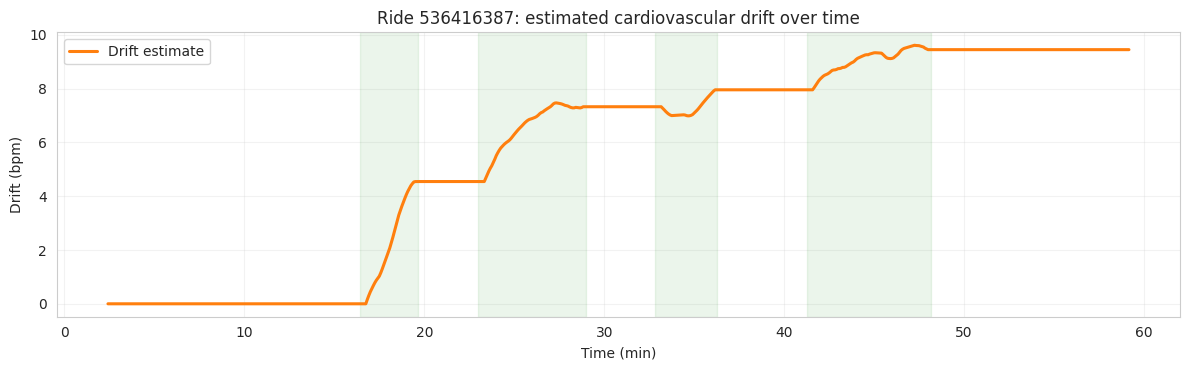

In [ ]:
# Cell 19b — Demo ride drift estimate only

from matplotlib.ticker import MultipleLocator

demo_r = df_final[df_final["ride_id"] == DEMO_RIDE_ID].sort_values("elapsed_seconds").copy()
demo_t = demo_r["elapsed_seconds"].values / 60.0
demo_corr = demo_r["corr_active"].fillna(0).astype(int).values

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(demo_t, demo_r["drift_est"].values, color="#ff7f0e", linewidth=2.2, label="Drift estimate")
shade_corr_regions(ax, demo_t, demo_corr, color="green", alpha=0.08)

ax.yaxis.set_major_locator(MultipleLocator(2))
ax.set_xlabel("Time (min)")
ax.set_ylabel("Drift (bpm)")
ax.set_title(f"Ride {DEMO_RIDE_ID}: estimated cardiovascular drift over time")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/19d_demo_drift_only.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 20 — Resume helper

print("Available checkpoints:")
for f in sorted(os.listdir(CHK_DIR)):
    print("-", f)


# df_feat = load_ckpt("02_features_steady")
# df_model = load_ckpt("03_expected_hr")
# df_final = load_ckpt("04_final_with_drift")


Available checkpoints:
- 01_features.parquet
- 02_features_steady.parquet
- 02_features_steady_relaxed_v1.parquet
- 03_expected_hr.parquet
- 03_expected_hr_relaxed_v1.parquet
- 04_final_with_drift.parquet
- 04_final_with_drift_relaxed_v1.parquet


In [ ]:
# Cell 20b — Build heart-rate zones for observed and effective HR

ZONE_BOUNDS = [
    ("Z1 Recovery", 0.50, 0.60),
    ("Z2 Endurance", 0.60, 0.70),
    ("Z3 Tempo", 0.70, 0.80),
    ("Z4 Threshold", 0.80, 0.90),
    ("Z5 High Intensity", 0.90, 1.01),
]

zone_table = pd.DataFrame({
    "Zone": [z[0] for z in ZONE_BOUNDS],
    "Lower_pct_HRmax": [z[1] for z in ZONE_BOUNDS],
    "Upper_pct_HRmax": [z[2] for z in ZONE_BOUNDS],
    "Lower_bpm": [round(z[1] * HRMAX, 1) for z in ZONE_BOUNDS],
    "Upper_bpm": [round(min(z[2], 1.0) * HRMAX, 1) for z in ZONE_BOUNDS],
})

display(zone_table)
zone_table.to_csv(f"{TAB_DIR}/20h_zone_definitions.csv", index=False)

def hr_to_zone_idx(hr, hrmax=HRMAX):
    if pd.isna(hr):
        return np.nan
    frac = hr / hrmax
    for i, (_, lo, hi) in enumerate(ZONE_BOUNDS, start=1):
        if frac >= lo and frac < hi:
            return i
    if frac < ZONE_BOUNDS[0][1]:
        return 0
    return 5

df_zones = df_final.copy()
df_zones["zone_obs"] = df_zones["hr"].apply(hr_to_zone_idx)
df_zones["zone_eff"] = df_zones["hr_effective"].apply(hr_to_zone_idx)

df_zones["zone_obs_name"] = df_zones["zone_obs"].map({
    0: "Below Z1", 1: "Z1 Recovery", 2: "Z2 Endurance", 3: "Z3 Tempo", 4: "Z4 Threshold", 5: "Z5 High Intensity"
})
df_zones["zone_eff_name"] = df_zones["zone_eff"].map({
    0: "Below Z1", 1: "Z1 Recovery", 2: "Z2 Endurance", 3: "Z3 Tempo", 4: "Z4 Threshold", 5: "Z5 High Intensity"
})

df_zones["zone_diff"] = df_zones["zone_obs"] - df_zones["zone_eff"]

print(df_zones[["hr", "hr_effective", "zone_obs", "zone_eff", "zone_diff"]].head())
print("Done: df_zones created")


,Zone,Lower_pct_HRmax,Upper_pct_HRmax,Lower_bpm,Upper_bpm
0,Z1 Recovery,0.5,0.60,98.0,117.6
1,Z2 Endurance,0.6,0.70,117.6,137.2
2,Z3 Tempo,0.7,0.80,137.2,156.8
3,Z4 Threshold,0.8,0.90,156.8,176.4
4,Z5 High Intensity,0.9,1.01,176.4,196.0


      hr  hr_effective  zone_obs  zone_eff  zone_diff
0  125.0         125.0         2         2          0
1  123.0         123.0         2         2          0
2  117.0         117.0         1         1          0
3  107.0         107.0         1         1          0
4  103.0         103.0         1         1          0
Done: df_zones created


In [ ]:
# Cell 20i — Ride-level zone shift and late-stage zone misclassification

ZONE_BASE_START_SEC = 5 * 60
ZONE_BASE_END_SEC   = 12 * 60
ZONE_LATE_SEC       = 8 * 60
ZONE_MIN_SAMPLES    = 15

zone_rows = []

for rid, g in tqdm(df_zones.groupby("ride_id"), total=df_zones["ride_id"].nunique()):
    g = g.sort_values("elapsed_seconds").copy()

    base = g[
        (g["steady_final"] == 1) &
        (g["elapsed_seconds"] >= ZONE_BASE_START_SEC) &
        (g["elapsed_seconds"] <= ZONE_BASE_END_SEC)
    ].copy()

    corr = g[g["corr_active"] == 1].copy()
    if len(corr) < ZONE_MIN_SAMPLES:
        continue

    tmax_corr = float(corr["elapsed_seconds"].max())
    late = corr[corr["elapsed_seconds"] >= (tmax_corr - ZONE_LATE_SEC)].copy()

    if len(base) < ZONE_MIN_SAMPLES or len(late) < ZONE_MIN_SAMPLES:
        continue

    base_zone_obs = float(base["zone_obs"].mean())
    late_zone_obs = float(late["zone_obs"].mean())
    late_zone_eff = float(late["zone_eff"].mean())

    zone_rows.append({
        "ride_id": rid,
        "n_base": int(len(base)),
        "n_late": int(len(late)),
        "base_zone_obs_mean": base_zone_obs,
        "late_zone_obs_mean": late_zone_obs,
        "late_zone_eff_mean": late_zone_eff,
        "zone_shift_raw": float(late_zone_obs - base_zone_obs),
        "zone_shift_eff": float(late_zone_eff - base_zone_obs),
        "zone_shift_reduction": float((late_zone_obs - base_zone_obs) - (late_zone_eff - base_zone_obs)),
        "late_zone_misclass_frac": float((late["zone_obs"] != late["zone_eff"]).mean()),
        "late_zone_upshift_frac": float((late["zone_obs"] > late["zone_eff"]).mean()),
        "late_zone_same_frac": float((late["zone_obs"] == late["zone_eff"]).mean()),
        "mean_end_drift_late": float(late["drift_est"].mean()),
        "duration_min": float(g["elapsed_seconds"].max() / 60.0),
        "corr_frac": float(g["corr_active"].mean()),
        "steady_frac": float(g["steady_final"].mean())
    })

zone_eval_df = pd.DataFrame(zone_rows)
zone_eval_df.to_csv(f"{TAB_DIR}/20i_zone_shift_metrics.csv", index=False)

print("Zone evaluation rides:", len(zone_eval_df))
print(zone_eval_df[[
    "zone_shift_raw", "zone_shift_eff", "zone_shift_reduction",
    "late_zone_misclass_frac", "late_zone_upshift_frac"
]].describe())


  0%|          | 0/3535 [00:00<?, ?it/s]

Zone evaluation rides: 1008
       zone_shift_raw  zone_shift_eff  zone_shift_reduction  \
count     1008.000000     1008.000000           1008.000000   
mean         0.230237       -0.027390              0.257627   
std          0.648963        0.523971              0.286259   
min         -3.166667       -3.354167              0.000000   
25%         -0.102979       -0.258283              0.011174   
50%          0.157783        0.000000              0.134021   
75%          0.618724        0.202633              0.444940   
max          3.366753        2.634794              1.000000   

       late_zone_misclass_frac  late_zone_upshift_frac  
count              1008.000000             1008.000000  
mean                  0.257627                0.257627  
std                   0.286259                0.286259  
min                   0.000000                0.000000  
25%                   0.011174                0.011174  
50%                   0.134021                0.134021  
75%  

In [ ]:
# Cell 20j — Enhanced paired Wilcoxon signed-rank tests

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, norm

def paired_wilcoxon_test(df, col_a, col_b, label, alternative="greater"):
    """
    Runs Wilcoxon signed-rank test with effect size.
    Returns a dict row for summary table.
    """
    x = df[[col_a, col_b]].dropna()

    if len(x) == 0:
        return None

    diff = x[col_a] - x[col_b]

    # Remove zero differences
    diff_nonzero = diff[diff != 0]
    n = len(diff_nonzero)

    if n == 0:
        return None

    # Run test
    res = wilcoxon(
        x[col_a],
        x[col_b],
        alternative=alternative,
        zero_method="wilcox"
    )

    #  Effect size (r)
    # Convert statistic to z-score approximation
    mean_W = n * (n + 1) / 4
    std_W = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
    z = (res.statistic - mean_W) / std_W

    r = abs(z) / np.sqrt(n)

    return {
        "Comparison": label,
        "N": int(n),
        "Statistic": float(res.statistic),
        "p_value": float(res.pvalue),
        "Median_difference": float(np.median(diff)),
        "Effect_size_r": float(r),
        "Direction": "A > B" if np.median(diff) > 0 else "A < B"
    }


#  Run tests
wilcox_rows = []

row1 = paired_wilcoxon_test(
    eval_df,
    "mae_late_obs",
    "mae_late_eff",
    "Late MAE observed vs effective"
)

row2 = paired_wilcoxon_test(
    zone_eval_df,
    "zone_shift_raw",
    "zone_shift_eff",
    "Late zone shift raw vs effective"
)

for row in [row1, row2]:
    if row is not None:
        wilcox_rows.append(row)

wilcox_df = pd.DataFrame(wilcox_rows)

display(wilcox_df)

wilcox_df.to_csv(f"{TAB_DIR}/20j_wilcoxon_results.csv", index=False)

,Comparison,N,Statistic,p_value,Median_difference,Effect_size_r,Direction
0,Late MAE observed vs effective,911,300327.0,1.034063e-31,0.165349,0.386275,A > B
1,Late zone shift raw vs effective,769,296065.0,7.910814e-128,0.134021,0.866307,A > B


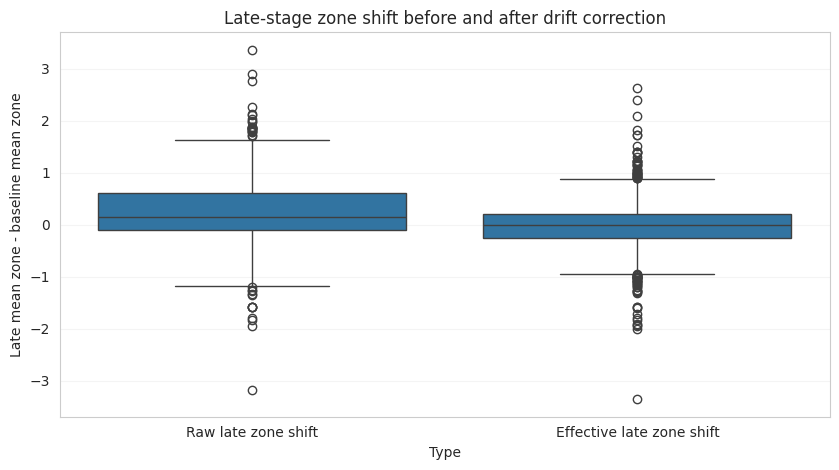

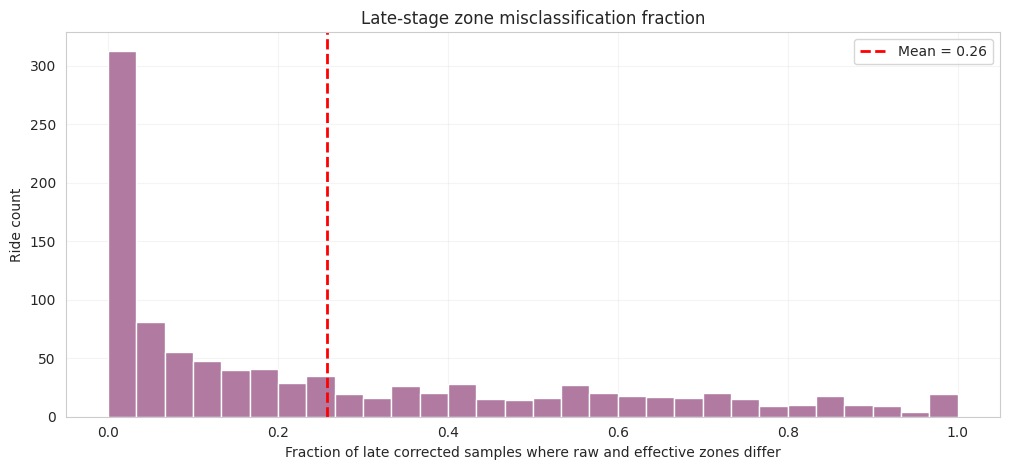

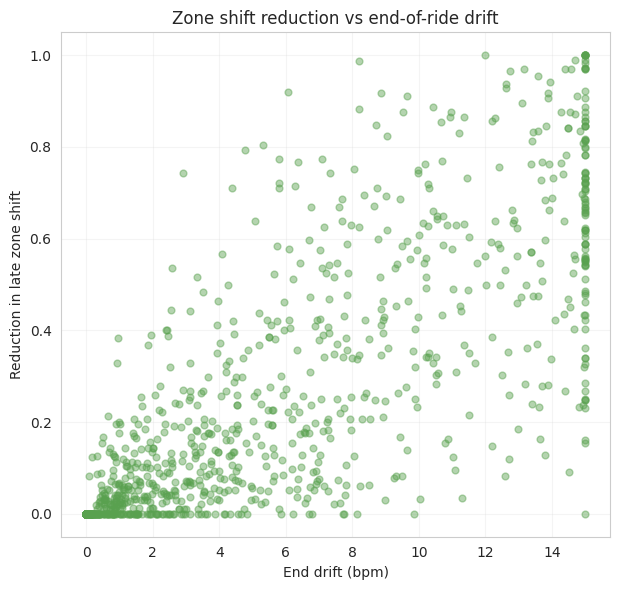

In [ ]:
# Cell 20k — Zone-focused charts for Chapter 4

import seaborn as sns

# 1) Raw vs effective zone shift boxplot
zone_plot_df = pd.DataFrame({
    "Zone shift": np.concatenate([
        zone_eval_df["zone_shift_raw"].values,
        zone_eval_df["zone_shift_eff"].values
    ]),
    "Type": (
        ["Raw late zone shift"] * len(zone_eval_df) +
        ["Effective late zone shift"] * len(zone_eval_df)
    )
})

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.boxplot(data=zone_plot_df, x="Type", y="Zone shift", ax=ax)
ax.set_title("Late-stage zone shift before and after drift correction")
ax.set_ylabel("Late mean zone - baseline mean zone")
ax.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20k_zone_shift_boxplot.png", dpi=180, bbox_inches="tight")
plt.show()

# 2) Misclassification fraction histogram
fig, ax = plt.subplots(figsize=(10.2, 4.8))
ax.hist(zone_eval_df["late_zone_misclass_frac"], bins=30, color="#b07aa1", edgecolor="white")
ax.axvline(zone_eval_df["late_zone_misclass_frac"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {zone_eval_df['late_zone_misclass_frac'].mean():.2f}")
ax.set_title("Late-stage zone misclassification fraction")
ax.set_xlabel("Fraction of late corrected samples where raw and effective zones differ")
ax.set_ylabel("Ride count")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20k_zone_misclassification_hist.png", dpi=180, bbox_inches="tight")
plt.show()

# 3) Zone shift reduction vs end drift
zone_plus = zone_eval_df.merge(
    eval_df[["ride_id", "end_drift", "late_improvement"]],
    on="ride_id", how="left"
)

fig, ax = plt.subplots(figsize=(6.3, 6.0))
ax.scatter(zone_plus["end_drift"], zone_plus["zone_shift_reduction"], alpha=0.45, s=24, color="#59a14f")
ax.set_title("Zone shift reduction vs end-of-ride drift")
ax.set_xlabel("End drift (bpm)")
ax.set_ylabel("Reduction in late zone shift")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20k_zone_shift_reduction_vs_end_drift.png", dpi=180, bbox_inches="tight")
plt.show()


/tmp/ipykernel_5839/1782345609.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  strat_table = strat_df.groupby(["duration_group"]).agg(


,duration_group,rides,mean_late_improvement,mean_zone_shift_reduction,mean_late_misclass_frac
0,Shorter,338,1.692491,0.170179,0.170179
1,Medium,335,2.353630,0.286248,0.286248
2,Longer,335,2.977834,0.317237,0.317237


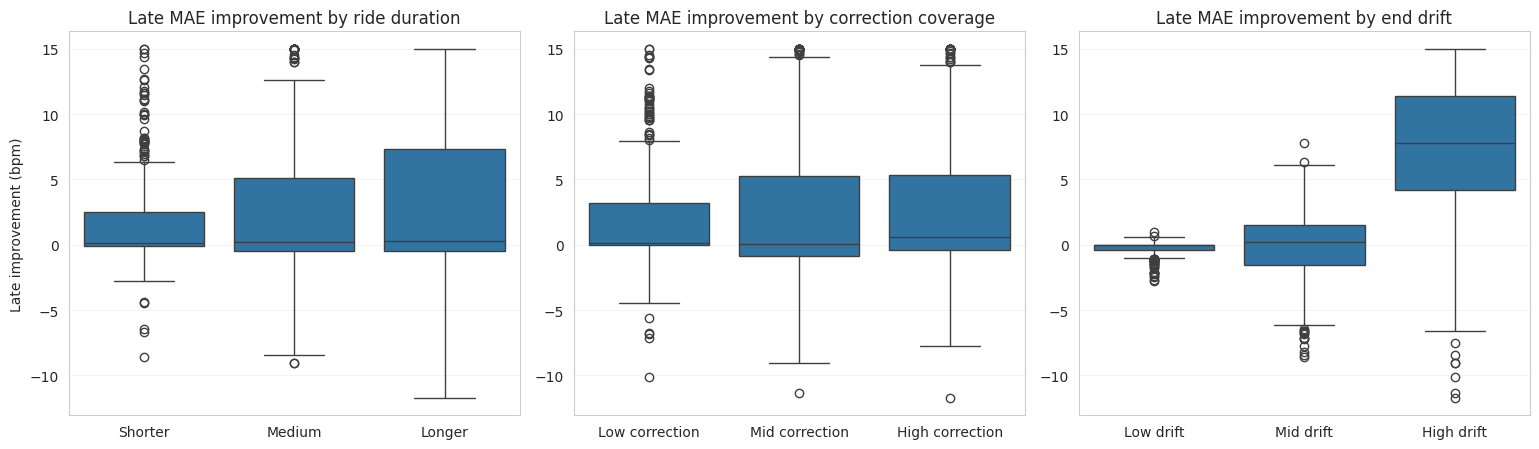

In [ ]:
# Cell 20l — Stratified analysis by ride characteristics

strat_df = eval_df.merge(
    zone_eval_df[["ride_id", "late_zone_misclass_frac", "zone_shift_reduction", "duration_min", "corr_frac", "steady_frac"]],
    on="ride_id", how="left"
)

strat_df["duration_group"] = pd.qcut(strat_df["duration_min"], q=3, labels=["Shorter", "Medium", "Longer"])
strat_df["corr_group"] = pd.qcut(strat_df["corr_frac"], q=3, labels=["Low correction", "Mid correction", "High correction"])
strat_df["drift_group"] = pd.qcut(strat_df["end_drift"], q=3, labels=["Low drift", "Mid drift", "High drift"])

strat_table = strat_df.groupby(["duration_group"]).agg(
    rides=("ride_id", "count"),
    mean_late_improvement=("late_improvement", "mean"),
    mean_zone_shift_reduction=("zone_shift_reduction", "mean"),
    mean_late_misclass_frac=("late_zone_misclass_frac", "mean"),
).reset_index()

display(strat_table)
strat_table.to_csv(f"{TAB_DIR}/20l_stratified_duration_table.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

sns.boxplot(data=strat_df, x="duration_group", y="late_improvement", ax=axes[0])
axes[0].set_title("Late MAE improvement by ride duration")
axes[0].set_xlabel("")
axes[0].set_ylabel("Late improvement (bpm)")
axes[0].grid(True, axis="y", alpha=0.2)

sns.boxplot(data=strat_df, x="corr_group", y="late_improvement", ax=axes[1])
axes[1].set_title("Late MAE improvement by correction coverage")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].grid(True, axis="y", alpha=0.2)

sns.boxplot(data=strat_df, x="drift_group", y="late_improvement", ax=axes[2])
axes[2].set_title("Late MAE improvement by end drift")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/20l_stratified_improvement_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
# Cell 20m — Analyze rides where correction worsened late MAE

fail_df = strat_df[strat_df["late_improvement"] <= 0].copy()
good_df = strat_df[strat_df["late_improvement"] > 0].copy()

failure_summary = pd.DataFrame({
    "Metric": [
        "Failure rides",
        "Successful rides",
        "Mean duration (failure)",
        "Mean duration (success)",
        "Mean correction fraction (failure)",
        "Mean correction fraction (success)",
        "Mean end drift (failure)",
        "Mean end drift (success)",
        "Mean baseline MAE (failure)",
        "Mean baseline MAE (success)"
    ],
    "Value": [
        int(len(fail_df)),
        int(len(good_df)),
        round(fail_df["duration_min"].mean(), 2),
        round(good_df["duration_min"].mean(), 2),
        round(fail_df["corr_frac"].mean(), 3),
        round(good_df["corr_frac"].mean(), 3),
        round(fail_df["end_drift"].mean(), 2),
        round(good_df["end_drift"].mean(), 2),
        round(fail_df["mae_base_obs"].mean(), 2),
        round(good_df["mae_base_obs"].mean(), 2),
    ]
})

display(failure_summary)
failure_summary.to_csv(f"{TAB_DIR}/20m_failure_case_summary.csv", index=False)


,Metric,Value
0,Failure rides,450.000
1,Successful rides,558.000
2,Mean duration (failure),55.390
3,Mean duration (success),55.240
4,Mean correction fraction (failure),0.349
5,Mean correction fraction (success),0.364
6,Mean end drift (failure),2.150
7,Mean end drift (success),8.600
8,Mean baseline MAE (failure),3.130
9,Mean baseline MAE (success),2.700
